In [14]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import geodatasets
import contextily as cx



training_df = pd.read_csv("../Data/water_quality_training_dataset.csv")
testing_df = pd.read_csv("../Data/submission_template.csv")

In [15]:
training_df


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0
...,...,...,...,...,...,...
9314,-27.527500,30.858056,23-12-2015,38.900,134.0,20.0
9315,-26.861111,28.884722,23-12-2015,115.800,388.0,20.0
9316,-26.984722,26.632278,23-12-2015,104.874,835.0,148.0
9317,-27.935000,26.126667,23-12-2015,128.000,305.0,28.0


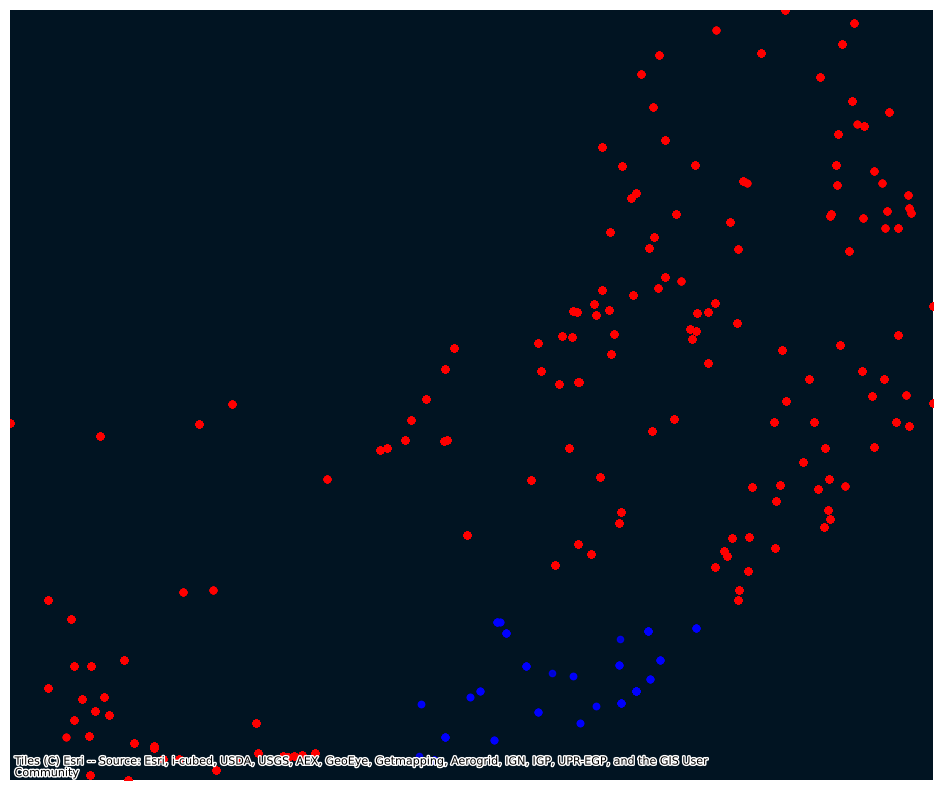

In [16]:
training_gdf = gpd.GeoDataFrame(
    training_df, geometry=gpd.points_from_xy(training_df["Longitude"],training_df["Latitude"], crs="EPSG:3857")
)

testing_gdf = gpd.GeoDataFrame(
    testing_df, geometry=gpd.points_from_xy(testing_df["Longitude"],testing_df["Latitude"], crs="EPSG:3857")
)


world = gpd.read_file(geodatasets.get_path('naturalearth.land'))


# reproject to Web Mercator for basemap tiles
train_3857 = training_gdf.to_crs(epsg=3857)
test_3857  = testing_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))

# plot points
train_3857.plot(ax=ax, color="red", markersize=20, alpha=0.8)
test_3857.plot(ax=ax, color="blue", markersize=20, alpha=0.8)

# zoom to data (nice tight bounds)
minx, miny, maxx, maxy = train_3857.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# satellite basemap (high-res depends on zoom)
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, zoom=10)

ax.set_axis_off()
plt.tight_layout()
plt.show()



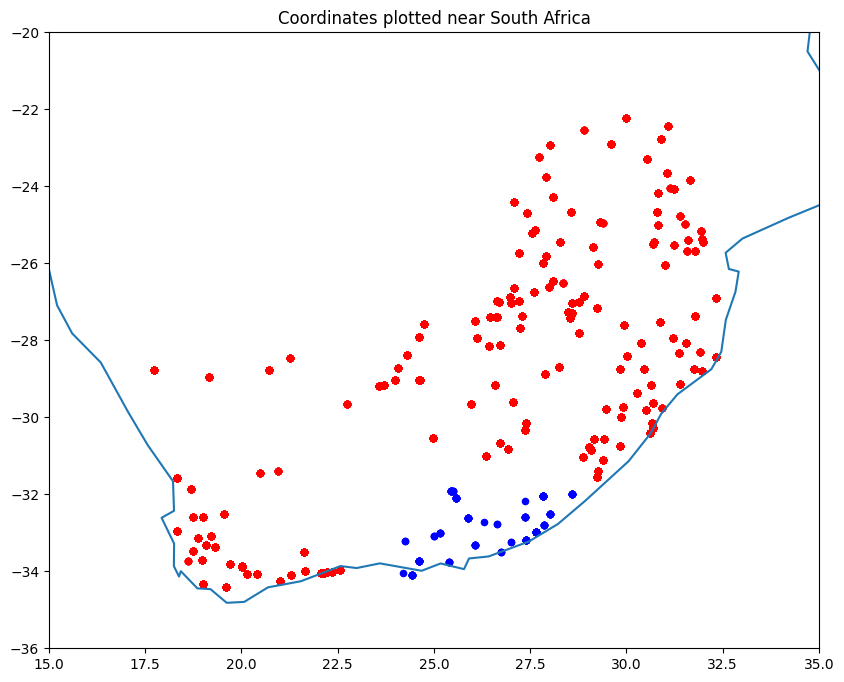

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))

world.boundary.plot(ax=ax)
training_gdf.plot(ax=ax, color="red", marker="o", markersize=20)
testing_gdf.plot(ax=ax, color="blue", marker="o", markersize=20)

# South Africa-ish extent (tweak as needed)
ax.set_xlim([15, 35])
ax.set_ylim([-36, -20])

plt.title("Coordinates plotted near South Africa")
plt.show()

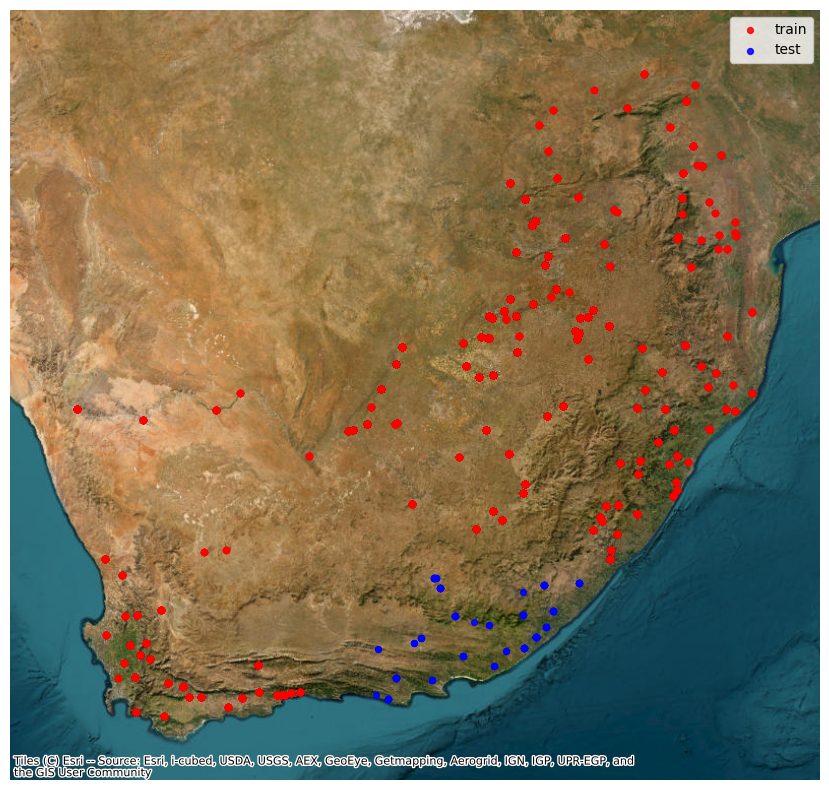

In [17]:
# Build GeoDataFrames (EPSG:4326)
training_gdf = gpd.GeoDataFrame(
    training_df,
    geometry=gpd.points_from_xy(training_df["Longitude"], training_df["Latitude"]),
    crs="EPSG:4326",
)
testing_gdf = gpd.GeoDataFrame(
    testing_df,
    geometry=gpd.points_from_xy(testing_df["Longitude"], testing_df["Latitude"]),
    crs="EPSG:4326",
)

# Reproject for basemap
train_3857 = training_gdf.to_crs(epsg=3857)
test_3857  = testing_gdf.to_crs(epsg=3857)

# Combine bounds from BOTH
all_pts = pd.concat([train_3857[["geometry"]], test_3857[["geometry"]]], ignore_index=True)
all_pts = gpd.GeoDataFrame(all_pts, geometry="geometry", crs=train_3857.crs)

minx, miny, maxx, maxy = all_pts.total_bounds
padx = (maxx - minx) * 0.10
pady = (maxy - miny) * 0.10

fig, ax = plt.subplots(figsize=(10, 8))

# Plot points
train_3857.plot(ax=ax, color="red", markersize=18, alpha=0.85, label="train")
test_3857.plot(ax=ax, color="blue", markersize=18, alpha=0.85, label="test")

# Set extent (with padding)
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)

# Add satellite basemap AFTER extent is set
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, zoom="auto")

ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
len(training_df)

9319